<a href="https://colab.research.google.com/github/tmorenom/MyRep_TMM2025/blob/main/Actividad5Preprocesamiento_A01840597.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: TERESA DE JESUS MORENO MARTINEZ
*   MATRÍCULA: A01840597

En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

* `id`: Identificador único de cada paciente
* `age`: Edad del paciente en años
* `origin`: Lugar de estudio
* `sex`: Masculino / Femenino
* `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
* `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
* `chol`: Colesterol sérico en mg/dl
* `fbs`: Si el azúcar en ayunas > 120 mg/dl
* `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
* `thalach`: Frecuencia cardíaca máxima alcanzada
* `exang`: Angina inducida por ejercicio (Verdadero / Falso)
* `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
* `slope`: Pendiente del segmento ST en el pico de ejercicio
* `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
* `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
* `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.
* Haz que la columna `id` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.

In [2]:
#Descarga el archivo: heart_disease.csv y guarda, en un dataframe (cardio_df), todos sus registros.
cardio_df=pd.read_csv ('heart_disease.csv')

# Haz que la columna id sea el índice del dataframe.
cardio_df.set_index('id', inplace=True)

#Utiliza el método info() del dataframe, para obtener el resumen de los tipos de datos
print(cardio_df.info)

#¿Cuántas columnas son numéricas ?
num_columnas_numericas = len(cardio_df.select_dtypes(include=['number']).columns)
print(f"Columnas numéricas: {num_columnas_numericas}")

#¿Cuántas columnas son de texto ?
num_columnas_texto = len(cardio_df.select_dtypes(include=['object', 'string']).columns)
print(f"Columnas de texto: {num_columnas_texto}")

#Determina la cantidad de valores únicos por columna.
valores_unicos = cardio_df.nunique()
print(f"Valores únicos por columna: {valores_unicos}")
#print(valores_unicos)




<bound method DataFrame.info of      age     sex         origin               cp  trestbps   chol    fbs  \
id                                                                         
1     63    Male      Cleveland   typical angina     145.0  233.0   True   
2     67    Male      Cleveland     asymptomatic     160.0  286.0  False   
3     67    Male      Cleveland     asymptomatic     120.0  229.0  False   
4     37    Male      Cleveland      non-anginal     130.0  250.0  False   
5     41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...     ...            ...              ...       ...    ...    ...   
916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
920   62    Male  VA Long Beach  atypical angina     120

2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.
* Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.

In [3]:

#Examina las variables numéricas que presentan pocos valores únicos
# Primero identifico que variables son númericas
df_numeric = cardio_df.select_dtypes(include=np.number)
df_texto = cardio_df.select_dtypes(exclude=['number'])
print(f"Variables numéricas: {df_numeric.columns}")
print(f"Variables no numéricas:{df_texto.columns}")
print(f"Solo identifico 'ca' y 'num' siendo numéricas y con pocos valores únicos <5 ")

# Convierte a categóricas ordinales y ordenalas
orden_ca = ['0', '1', '2', '3']
cardio_df['ca'] = pd.to_numeric(cardio_df['ca'], errors='coerce')
cardio_df['ca'] = cardio_df['ca'].apply(lambda x: str(int(x)) if pd.notna(x) and (x == int(x)) else np.nan)
cat_type_ca = pd.CategoricalDtype(categories=orden_ca, ordered=True)
cardio_df['ca'] = cardio_df['ca'].astype(cat_type_ca)

orden_num = ['0', '1', '2', '3', '4'] # 0 = sano, 1-4 = enfermedad
cardio_df['num'] = pd.to_numeric(cardio_df['num'], errors='coerce')
cardio_df['num'] = cardio_df['num'].apply(lambda x: str(int(x)) if pd.notna(x) and (x == int(x)) else np.nan)
cat_type_num = pd.CategoricalDtype(categories=orden_num, ordered=True)
cardio_df['num'] = cardio_df['num'].astype(cat_type_num)

df_numeric = cardio_df.select_dtypes(include=np.number)
df_texto = cardio_df.select_dtypes(exclude=['number'])

print(cardio_df.head())





Variables numéricas: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')
Variables no numéricas:Index(['sex', 'origin', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')
Solo identifico 'ca' y 'num' siendo numéricas y con pocos valores únicos <5 
    age     sex     origin               cp  trestbps   chol    fbs  \
id                                                                    
1    63    Male  Cleveland   typical angina     145.0  233.0   True   
2    67    Male  Cleveland     asymptomatic     160.0  286.0  False   
3    67    Male  Cleveland     asymptomatic     120.0  229.0  False   
4    37    Male  Cleveland      non-anginal     130.0  250.0  False   
5    41  Female  Cleveland  atypical angina     130.0  204.0  False   

           restecg  thalch  exang  oldpeak        slope ca               thal  \
id                                                                              
1   lv hypertrophy   150.0  False      2.3 

3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.
* Para las numéricas, incluye el sesgo y la curtosis.
* Para las categóricas, imprime además las tablas de frecuencia.

In [4]:
df_numeric = cardio_df.select_dtypes(include=np.number)
df_texto = cardio_df.select_dtypes(exclude=['number'])

print("--- Estadísticas descriptivas para variables numéricas ---")
# Estadísticas descriptivas, incluyendo sesgo y curtosis para las numéricas
Est_descriptivas = df_numeric.describe()
sesgo = df_numeric.skew()
curtosis = df_numeric.kurt()
Est_descriptivas.loc['skew'] = sesgo
Est_descriptivas.loc['kurt'] = curtosis

display(Est_descriptivas)

print("\n--- Tablas de frecuencia para variables categóricas ---")
# Estadísticas para las categoricas (imprimir tablas de frecuencia)
for col in df_texto.columns:
    print(f"\nFrecuencia de {col}:")
    display(cardio_df[col].value_counts(dropna=False))

--- Estadísticas descriptivas para variables numéricas ---


,age,trestbps,chol,thalch,oldpeak
count,918.000000,859.000000,888.000000,863.000000,856.000000
mean,53.530501,132.294529,242.189189,137.528389,0.880607
std,9.412783,18.535875,53.424806,25.950226,1.091840
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,216.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000
skew,-0.193710,0.630411,1.640672,-0.209319,1.037990
kurt,-0.382511,0.632992,6.573848,-0.483939,1.119834



--- Tablas de frecuencia para variables categóricas ---

Frecuencia de sex:


,count
sex,
Male,724
Female,194



Frecuencia de origin:


...

,count
ca,
NaN,609
0,181
1,67
2,41
3,20



Frecuencia de thal:


,count
thal,
NaN,484
normal,196
reversable defect,192
fixed defect,46



Frecuencia de num:


,count
num,
0,411
1,263
2,109
3,107
4,28


4. Calcula el porcentaje de valores faltantes en cada columna.
* Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
* Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
* Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

Porcentaje de valores faltantes por columna:
age          0.000000
sex          0.000000
origin       0.000000
cp           0.000000
trestbps     6.427015
chol         3.267974
fbs          9.694989
restecg      0.000000
thalch       5.991285
exang        5.991285
oldpeak      6.753813
slope       33.551198
ca          66.339869
thal        52.723312
num          0.000000
dtype: float64
Columnas a eliminar (más del 30% de valores faltantes): ['slope', 'ca', 'thal']


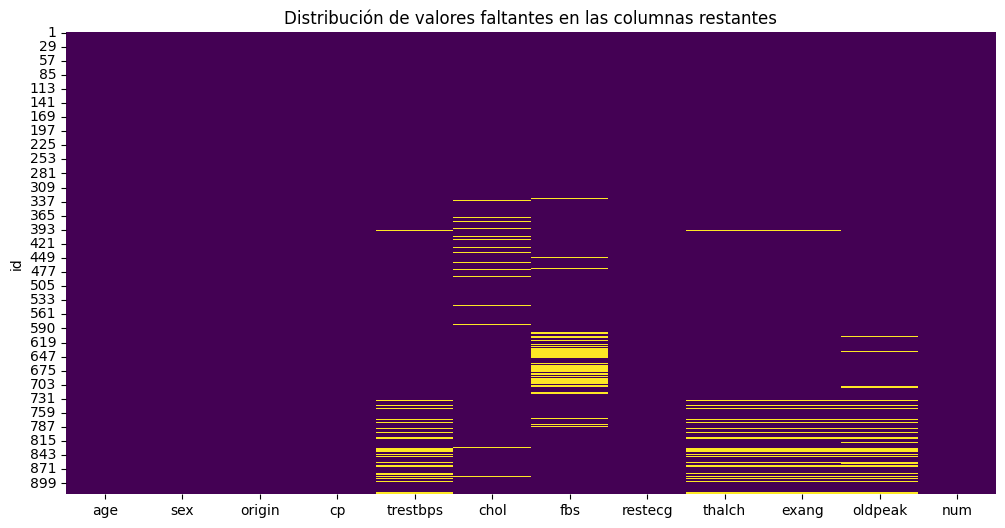

Valores faltantes restantes por columna:
age          0
sex          0
origin       0
cp           0
trestbps    59
chol        30
fbs         89
restecg      0
thalch      55
exang       55
oldpeak     62
num          0
dtype: int64
Observo que las variables ausentes al mismo tiempo son 'thalch' y 'exang'
con 55 valores faltantes en ambas
Al no ser experta médica mi punto de vista personal y analizando las descripciones 
de estas variables, es que tiene sentido, ya que si no hay una frecuencia 
cardíaca máxima alcanzada no hay una angina inducida por ejercicio


In [5]:
#Calcula el porcentaje de valores faltantes en cada columna.
Porcentajes_faltantes = (cardio_df.isnull().sum() / len(cardio_df)) * 100
print("Porcentaje de valores faltantes por columna:")
print(Porcentajes_faltantes)

#Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
columnas_a_elim = Porcentajes_faltantes[Porcentajes_faltantes > 30].index.tolist()
print(f"Columnas a eliminar (más del 30% de valores faltantes): {columnas_a_elim}")
cardio_df.drop(columns=columnas_a_elim, inplace=True)

#Crea un mapa de calor
plt.figure(figsize=(12, 6))
sns.heatmap(cardio_df.isnull(), cbar=False, cmap='viridis')
plt.title('Distribución de valores faltantes en las columnas restantes')
plt.show()

print("Valores faltantes restantes por columna:")
print(cardio_df.isnull().sum())

print ("Observo que las variables ausentes al mismo tiempo son 'thalch' y 'exang'")
print("con 55 valores faltantes en ambas")
print("Al no ser experta médica mi punto de vista personal y analizando las descripciones ")
print ("de estas variables, es que tiene sentido, ya que si no hay una frecuencia ")
print("cardíaca máxima alcanzada no hay una angina inducida por ejercicio")

5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

* ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  *   Numéricas: `age`, `chol`
  *   Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.
* Incluye las conclusiones del análisis con los resultados obtenidos.
* Justifica si el mecanismo de faltantes de `thalch` es MCAR (*Missing Completely at Random*) o MAR (*Missing at Random*).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

In [6]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

In [7]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

id
1    False
2    False
3    False
4    False
5    False
Name: thalch, dtype: bool


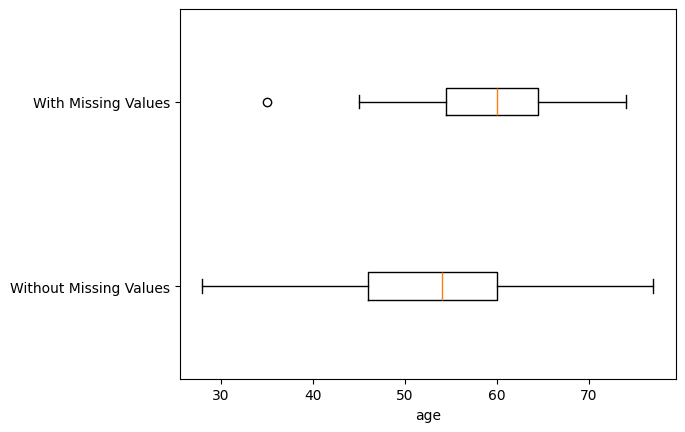

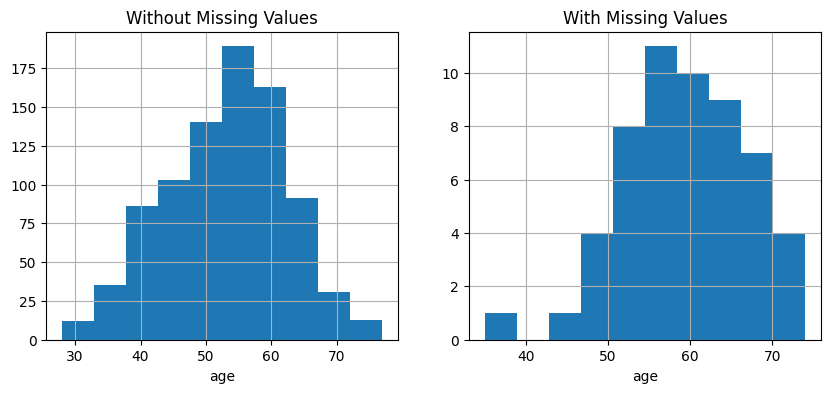

p-value of t-test: 1.5041244185890902e-06


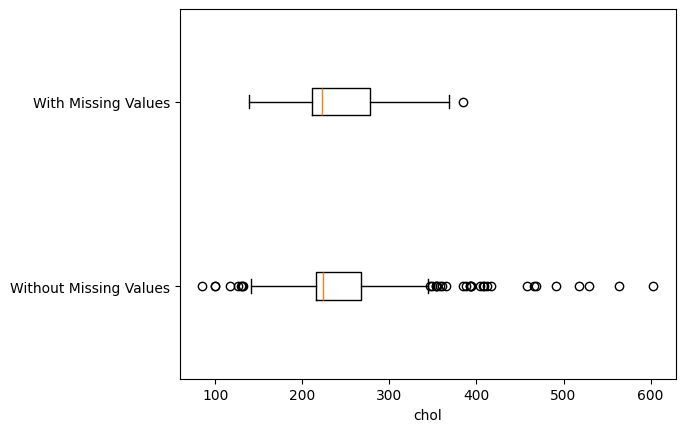

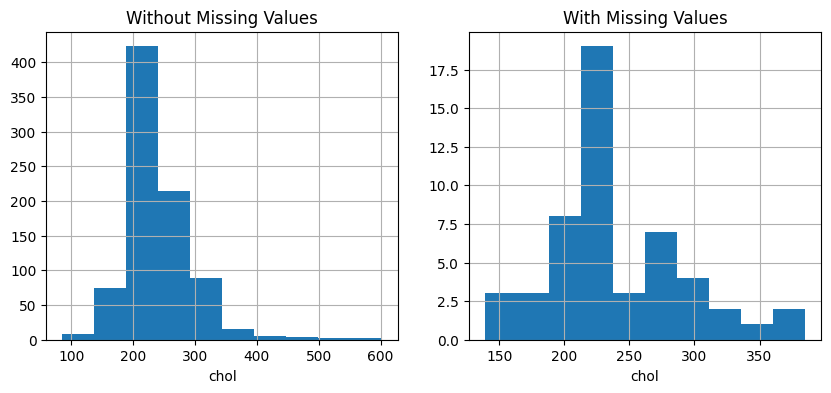

p-value of t-test: 0.7165289974295672


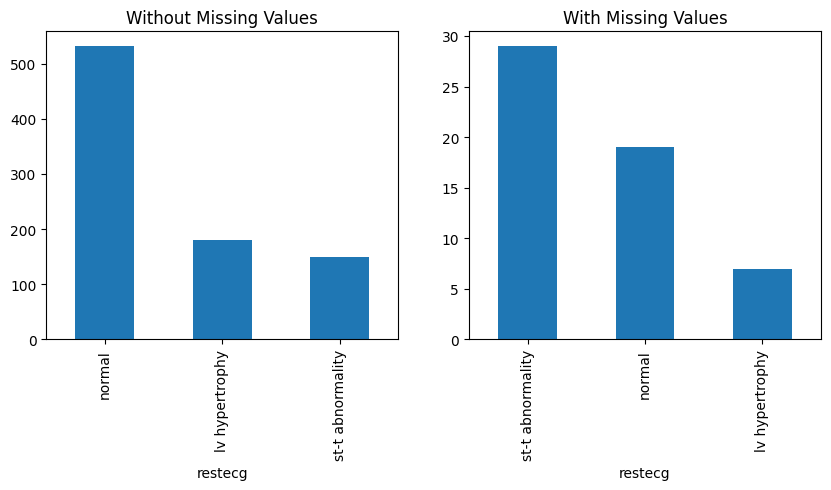

p-value of Chi_squared test: 1.1472889573985467e-09


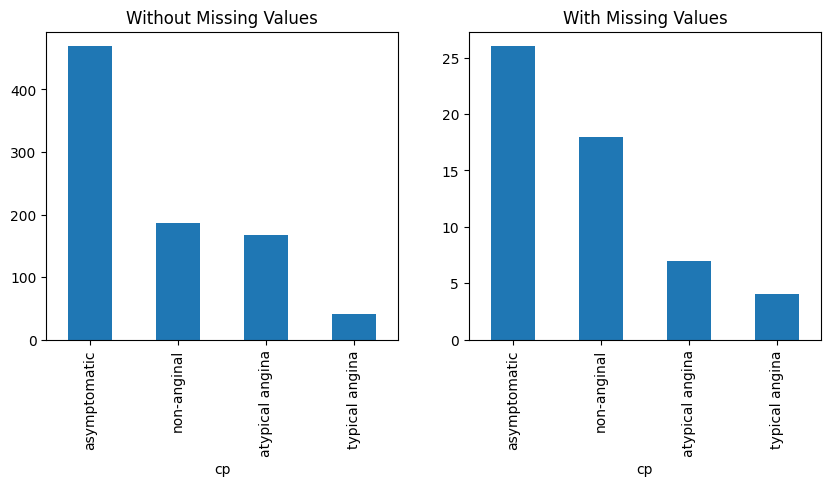

p-value of Chi_squared test: 0.15420097177251701

Encuentro relación entre la presencia de valores faltantes en la Frecuencia cardíaca máxima alcanzada
con respecto  a la edad y los resultados del electrocardiograma en reposo
ya que en ambos casos los valores son muy bajos pero no los considero contundentes
ya que no hay una relación directa entre los casos donde hay Frecuencia maxima alcanzada y los demás valores
además que hay casos donde el colesterol está alto sin importar la edad
hay casos en donde no hay dolor torácico con la frecuencia máxima alcanzada
hay casos en donde los resultados del electrocardiograma se muestran normales y el colesterol
puede o no puede estar alto, hay casos con y sin dolor
Por lo tanto, el mecanismo de valores faltantes para thalch es MAR (Missing At Random)


In [11]:
BM_MV = cardio_df['thalch'].isna()
print(BM_MV.head())
Diagnose_MV_Numerical(cardio_df, 'age', BM_MV)
Diagnose_MV_Numerical(cardio_df, 'chol', BM_MV)
Diagnose_MV_Categorical(cardio_df, 'restecg', BM_MV)
Diagnose_MV_Categorical(cardio_df, 'cp', BM_MV)

#Incluye las conclusiones del análisis con los resultados obtenidos.

print ("\nEncuentro relación entre la presencia de valores faltantes en la Frecuencia cardíaca máxima alcanzada")
print (f"con respecto  a la edad y los resultados del electrocardiograma en reposo")
print (f"ya que en ambos casos los valores son muy bajos pero no los considero contundentes")
print (f"ya que no hay una relación directa entre los casos donde hay Frecuencia maxima alcanzada y los demás valores")
print (f"además que hay casos donde el colesterol está alto sin importar la edad")
print (f"hay casos en donde no hay dolor torácico con la frecuencia máxima alcanzada")
print (f"hay casos en donde los resultados del electrocardiograma se muestran normales y el colesterol")
print (f"puede o no puede estar alto, hay casos con y sin dolor")
print (f"Por lo tanto, el mecanismo de valores faltantes para thalch es MAR (Missing At Random)")

6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

* Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 4) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
* Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.

Valores faltantes antes de la imputación por grupo:
thalch    55
exang     55
dtype: int64

Valores faltantes después de la imputación por grupo (thalch y exang):
thalch    0
exang     0
dtype: int64


/tmp/ipython-input-2772538363.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cardio_df['exang'] = cardio_df.groupby('restecg')['exang'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False))


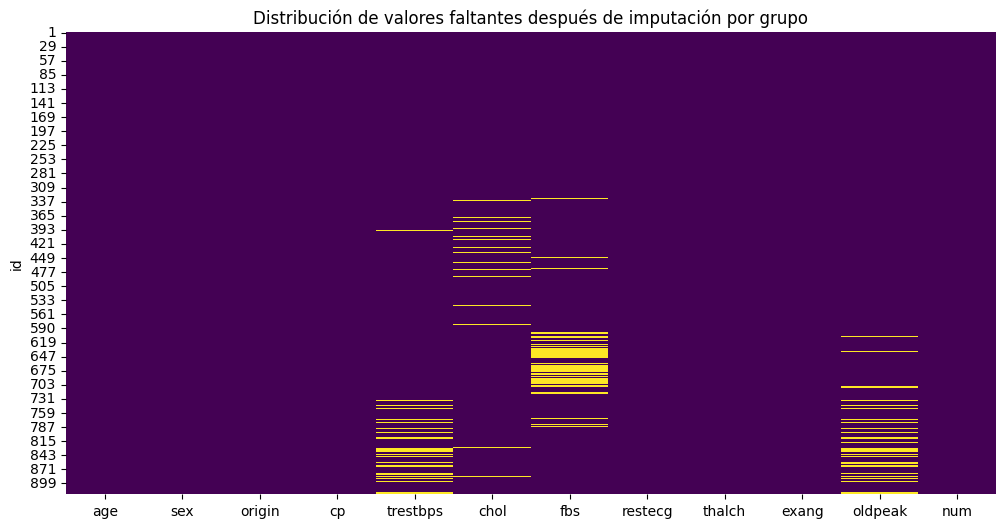

In [12]:

print("Valores faltantes antes de la imputación por grupo:")
print(cardio_df[['thalch', 'exang']].isnull().sum())

# Imputar 'thalch' (numérica) con la mediana por grupo de 'restecg'
cardio_df['thalch'] = cardio_df.groupby('restecg')['thalch'].transform(lambda x: x.fillna(x.median()))

# Imputar 'exang' (booleana/categórica) con la moda por grupo de 'restecg'
# La moda de una serie booleana devolverá True o False. Si hay un empate, se toma el primer valor.
cardio_df['exang'] = cardio_df.groupby('restecg')['exang'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False))

print("\nValores faltantes después de la imputación por grupo (thalch y exang):")
print(cardio_df[['thalch', 'exang']].isnull().sum())

# Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.
plt.figure(figsize=(12, 6))
sns.heatmap(cardio_df.isnull(), cbar=False, cmap='viridis')
plt.title('Distribución de valores faltantes después de imputación por grupo')
plt.show()

7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn
* Justifica la estrategia (*mean, median, most_frequent*) que emplees en cada caso.


In [13]:
from sklearn.impute import SimpleImputer

# Mostrar los valores faltantes actuales antes de la imputación
print("Valores faltantes antes de la imputación general:")
print(cardio_df.isnull().sum()[cardio_df.isnull().sum() > 0])

# Imputar 'trestbps' (presión arterial en reposo), se usa la mediana por robustez.
imputer_trestbps = SimpleImputer(strategy='median')
cardio_df['trestbps'] = imputer_trestbps.fit_transform(cardio_df[['trestbps']]).flatten()
imputer_trestbps.fit_transform(cardio_df[['trestbps']]).flatten()

# Imputar 'chol' (colesterol), se usa la mediana por robustez.
imputer_chol = SimpleImputer(strategy='median')
cardio_df['chol'] = imputer_chol.fit_transform(cardio_df[['chol']]).flatten()

# Imputar 'fbs' (azúcar en ayunas): Categórica, se usa la moda.
imputer_fbs = SimpleImputer(strategy='most_frequent')
cardio_df['fbs'] = imputer_fbs.fit_transform(cardio_df[['fbs']]).flatten()

# Imputar 'oldpeak' (depresipon del segmento ST), se usa la mediana por robustez.
imputer_oldpeak = SimpleImputer(strategy='median')
cardio_df['oldpeak'] = imputer_oldpeak.fit_transform(cardio_df[['oldpeak']]).flatten()

# Mostrar los valores faltantes después de la imputación para confirmar
print("\nValores faltantes después de la imputación general:")
print(cardio_df.isnull().sum()[cardio_df.isnull().sum() > 0])



Valores faltantes antes de la imputación general:
trestbps    59
chol        30
fbs         89
oldpeak     62
dtype: int64

Valores faltantes después de la imputación general:
Series([], dtype: int64)


8. Dibuja boxplots de todas las variables numéricas.
* Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.

Valores atípicos identificados mediante boxplots:


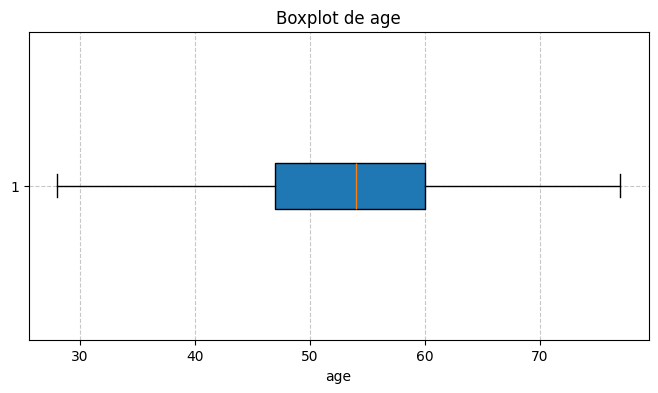

- age: No se encontraron valores atípicos.


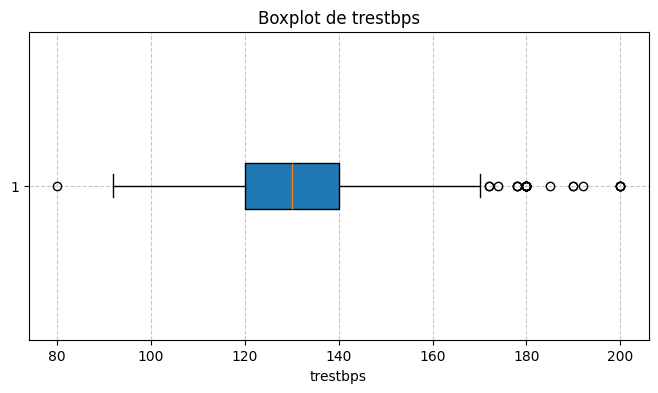

- trestbps: [80.0, 172.0, 174.0, 178.0, 180.0, 185.0, 190.0, 192.0, 200.0]


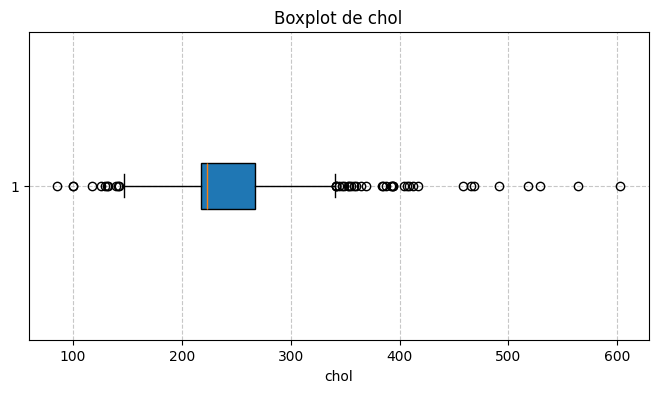

- chol: [85.0, 100.0, 117.0, 126.0, 129.0, 131.0, 132.0, 139.0, 141.0, 142.0, 342.0, 344.0, 347.0, 349.0, 353.0, 354.0, 355.0, 358.0, 360.0, 365.0, 369.0, 384.0, 385.0, 388.0, 392.0, 393.0, 394.0, 404.0, 407.0, 409.0, 412.0, 417.0, 458.0, 466.0, 468.0, 491.0, 518.0, 529.0, 564.0, 603.0]


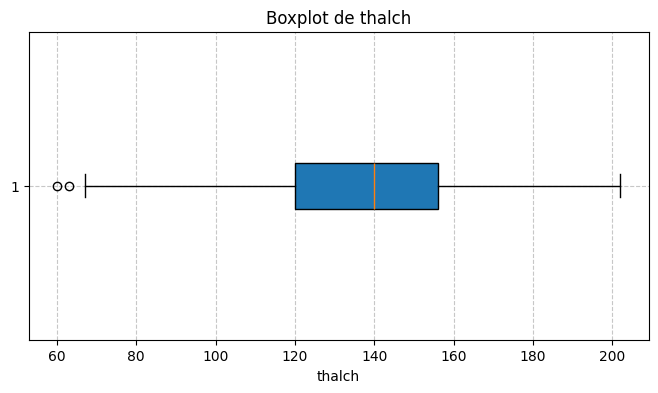

- thalch: [60.0, 63.0]


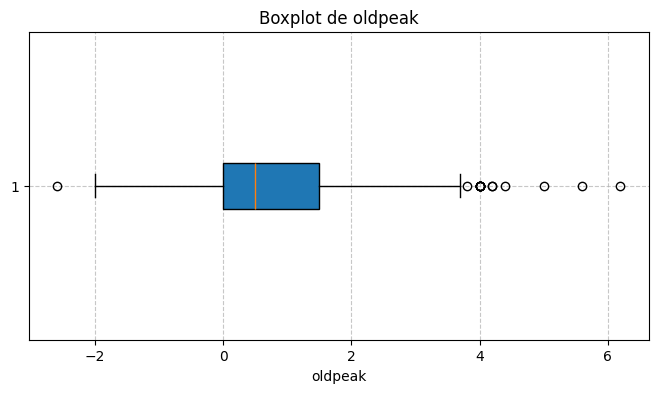

- oldpeak: [-2.6, 3.8, 4.0, 4.2, 4.4, 5.0, 5.6, 6.2]


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identificar todas las columnas numéricas
numerical_cols = cardio_df.select_dtypes(include=np.number).columns

print("Valores atípicos identificados mediante boxplots:")

# 2. Iterar sobre cada columna numérica y generar un boxplot
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    bp = plt.boxplot(cardio_df[col].dropna(), vert=False, patch_artist=True)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 3. Extraer los valores atípicos del objeto boxplot
    outliers = [flier.get_ydata() for flier in bp['fliers']]
    outliers = [flier.get_xdata() for flier in bp['fliers']]

    if outliers and len(outliers[0]) > 0:
        print(f"- {col}: {np.unique(np.concatenate(outliers)).tolist()}")
    else:
        print(f"- {col}: No se encontraron valores atípicos.")

9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).
* Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
* Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.

In [15]:
import numpy as np

Q1 = cardio_df['trestbps'].quantile(0.25)
Q3 = cardio_df['trestbps'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (trestbps): {Q1}")
print(f"Q3 (trestbps): {Q3}")
print(f"IQR (trestbps): {IQR}")
print(f"Límite Inferior (trestbps): {lower_bound}")
print(f"Límite Superior (trestbps): {upper_bound}")

iqr_outliers = cardio_df[(cardio_df['trestbps'] < lower_bound) | (cardio_df['trestbps'] > upper_bound)]['trestbps'].sort_values().unique().tolist()

print(f"\nValores atípicos identificados por IQR para 'trestbps': {iqr_outliers}")

graphical_outliers_trestbps = [80.0, 172.0, 174.0, 178.0, 180.0, 185.0, 190.0, 192.0, 200.0]

iqr_set = set(iqr_outliers)
graphical_set = set(graphical_outliers_trestbps)

print(f"\nValores atípicos gráficos (previos) para 'trestbps': {graphical_outliers_trestbps}")

if iqr_set == graphical_set:
    print("Los valores atípicos identificados por IQR coinciden exactamente con los obtenidos gráficamente.")
elif iqr_set.issubset(graphical_set):
    print("Los valores atípicos identificados por IQR son un subconjunto de los obtenidos gráficamente.")
elif graphical_set.issubset(iqr_set):
    print("Los valores atípicos obtenidos gráficamente son un subconjunto de los identificados por IQR.")
else:
    print("Los valores atípicos identificados por IQR y los obtenidos gráficamente tienen algunas diferencias.")
    print(f"Valores en IQR pero no en gráfico: {list(iqr_set - graphical_set)}")
    print(f"Valores en gráfico pero no en IQR: {list(graphical_set - iqr_set)}")

Q1 (trestbps): 120.0
Q3 (trestbps): 140.0
IQR (trestbps): 20.0
Límite Inferior (trestbps): 90.0
Límite Superior (trestbps): 170.0

Valores atípicos identificados por IQR para 'trestbps': [80.0, 172.0, 174.0, 178.0, 180.0, 185.0, 190.0, 192.0, 200.0]

Valores atípicos gráficos (previos) para 'trestbps': [80.0, 172.0, 174.0, 178.0, 180.0, 185.0, 190.0, 192.0, 200.0]
Los valores atípicos identificados por IQR coinciden exactamente con los obtenidos gráficamente.


10. Elimina los valores atípicos identificados de la variable `trestbps`.
* Dibuja el boxplot final para visualizar la distribución depurada.

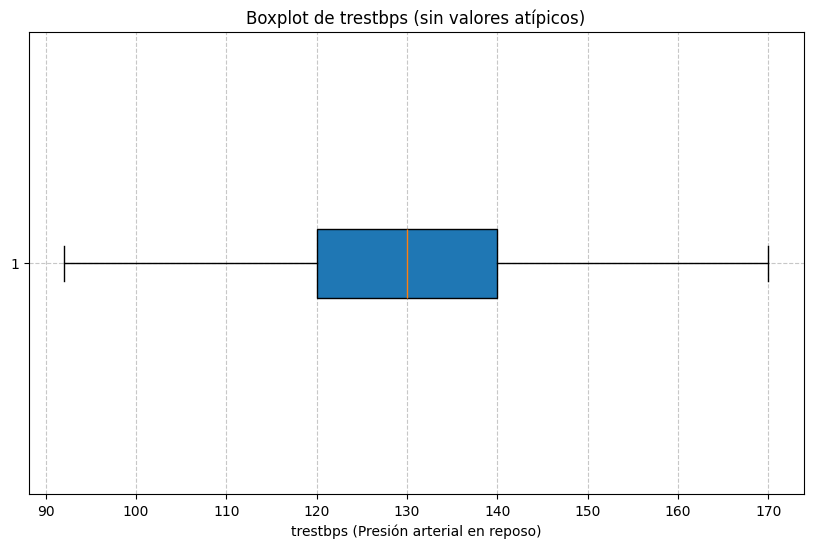

In [16]:
import matplotlib.pyplot as plt


# Eliminar los valores atípicos de 'trestbps'
cardio_df_depura = cardio_df[~cardio_df['trestbps'].isin(iqr_outliers)]

# Dibuja el boxplot final para visualizar la distribución depurada.
plt.figure(figsize=(10, 6))
plt.boxplot(cardio_df_depura['trestbps'].dropna(), vert=False, patch_artist=True)
plt.title('Boxplot de trestbps (sin valores atípicos)')
plt.xlabel('trestbps (Presión arterial en reposo)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()